# 🤝 *¡A testear se ha dicho! Análisis colaborativo de un A/B test*

---



🎯 *Objetivos académicos*

* Analizar datos reales de una prueba A/B para identificar resultados y posibles decisiones de negocio.
* Aplicar herramientas estadísticas (t-test para proporciones, visualización) para respaldar conclusiones.


## 🧪 *Group challenge: Decisiones basadas en datos (80 min)*

---

Una empresa de e-commerce está probando **dos colores diferentes de botón** en su landing page. El grupo B recibe un nuevo color y se busca evaluar si eso mejora la tasa de conversión.


Contiene:
- `User_ID`: ID único del usuario
- `Variant`: grupo experimental (`A` = control, `B` = tratamiento)
- `Clicks`: cantidad de clics por usuario
- `Conversions`: 1 si el usuario convirtió, 0 si no

Fuente : [A/B Testing for Button Color Variants Dataset](https://www.kaggle.com/datasets/tathagatachowdhury09/ab-testing-for-button-color-variants-dataset)

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
buttom_color_dataset= pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/datasets/buttom_color_ab_data.csv")

In [3]:
buttom_color_dataset.head()

,User_ID,Variant,Clicks,Conversions
0,2721,A,3,0
1,2241,A,2,0
2,9808,A,16,0
3,3804,A,3,0
4,4391,A,9,0


In [4]:
buttom_color_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   User_ID      20000 non-null  int64 
 1   Variant      20000 non-null  object
 2   Clicks       20000 non-null  int64 
 3   Conversions  20000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 625.1+ KB


✨ **Dinámica del Coding Challenge** ✨

Durante la siguiente actividad, nos dividiremos en *break rooms* para trabajar en equipos, simulando ser un verdadero equipo de datos en una empresa. Les pedimos que se organicen y asignen los siguientes roles:

- 👩‍💼 **Líder:** guía la discusión y asegura que el equipo avance.
- 📝 **Nota(s):** registra los puntos clave y hallazgos del grupo.
- 🗣️ **Moderador/a:** fomenta la participación y cuida los tiempos.

*¡No se preocupen!* Una misma persona puede asumir más de un rol si así lo prefieren.  
El objetivo es colaborar, analizar el reto y tomar decisiones como lo haría un equipo profesional, ¡aprovechando la diversidad de ideas y el trabajo conjunto!

📈 *Analisis esperados:*

- Define correctamente las hipotesis de interés
- Analiza las tasas de conversión por grupos
- Analiza la actividad por grupo (clics)
- Existe relación entre la actividad y la conversión

🎯 *Metas:*
- Presentar hallazgos con evidencia numérica
- Usar visualización como apoyo
- Identificar limitaciones del análisis
- Tomar una decisión realista como analistas de negocio

🧭 *Sección 4 — Discusión orientada (10 min)*

* ¿Declaro ganador al botón nuevo?
* ¿Qué más necesitaría para decidir con más confianza?
* ¿Hubo sesgos u omisiones posibles?



✅ *Cierre con reflexiones clave (5 min)*

* No hay experimento sin hipótesis clara.
* La significancia estadística no basta si no hay impacto real.
* Visualizar ayuda a pensar.
* Tus recomendaciones deben tener sentido para el negocio.


## Analisis exploratorio

In [6]:
buttom_color_dataset.head()

,User_ID,Variant,Clicks,Conversions
0,2721,A,3,0
1,2241,A,2,0
2,9808,A,16,0
3,3804,A,3,0
4,4391,A,9,0


Vamos a revisar

1. Revisar que solo sean dos grupos
2. Revisar que no haya usuarios que esten en los dos grupos
3. Revisar la cantidad de participantes por grupo
4. Tasa de conversion por grupo



In [9]:
buttom_color_dataset.Variant.unique(), buttom_color_dataset.User_ID.nunique()

(array(['A', 'B'], dtype=object), 20000)

<Axes: ylabel='Frequency'>

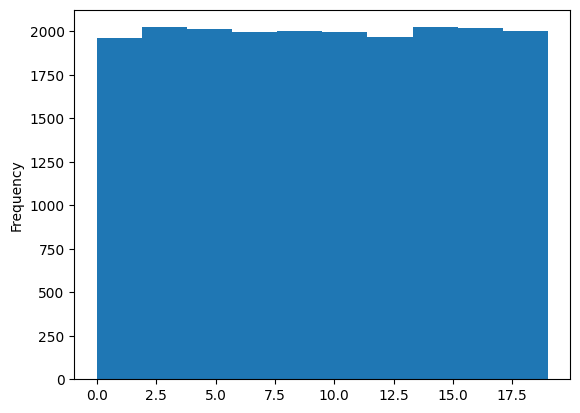

In [11]:
buttom_color_dataset.Clicks.plot(kind='hist')

In [12]:
buttom_color_dataset.describe()

,User_ID,Clicks,Conversions
count,20000.000000,20000.000000,20000.000000
mean,10000.500000,9.513450,0.034600
std,5773.647028,5.768603,0.182769
min,1.000000,0.000000,0.000000
25%,5000.750000,5.000000,0.000000
50%,10000.500000,10.000000,0.000000
75%,15000.250000,15.000000,0.000000
max,20000.000000,19.000000,1.000000


In [14]:
#Validar que no haya usuarios en más de dos pruebas

(
    buttom_color_dataset
      .groupby('User_ID',as_index=False)
      .agg( n_g = ('Variant','nunique'))
      .query("n_g>1")
)



,User_ID,n_g


In [15]:
#Descriptivo de los grupos

(
    buttom_color_dataset
      .groupby('Variant',as_index=False)
      .agg( n_part = ('User_ID','nunique'),
           tasa_conv = ('Conversions','mean'),
          avg_clics = ('Clicks','mean')

            )

)

,Variant,n_part,tasa_conv,avg_clics
0,A,10000,0.0270,9.5172
1,B,10000,0.0422,9.5097


## Diseño de la prueba A/B (Tasa de conversión)

---



### **Definir hipótesis**

* $H_0:$ El botón nuevo tiene la misma tasa de conversión o menor que el botón actual   $p_b \leq p_a$
* $H_1:$ El botón nuevo tiene una tasa de conversión mayor que el botón actual $p_b > p_a$

### **Nivel de significancia $\alpha$**

Definos una significancia del 0.05


In [20]:
from statsmodels.stats.proportion import proportions_ztest

In [21]:
exitos = [buttom_color_dataset.query('Variant == "B"').Conversions.sum(),buttom_color_dataset.query('Variant == "A"').Conversions.sum()]
n_obs= [1000,1000]
exitos
alpha= 0.05

In [23]:
stat,p_value = proportions_ztest(exitos,n_obs, alternative='larger')

print(f"Tenemos un {p_value=:.3f} entonces con {alpha=} ")
if p_value > alpha:
    print(f"Hay evidencia de que las tasa de conversión B es igual o menor que la de A")
else:
    print(f"No hay evidencia de que las tasa de conversión B es igual o menor que la de A")


Tenemos un p_value=0.000 entonces con alpha=0.05 
No hay evidencia de que las tasa de conversión B es igual o menor que la de A


### **Conclusión**

Al comparar los resultados de la conversión de clientes con el nuevo botón con respecto al anterior, estadísticamente notamos que el  botón nuevo tiene mejores resultados, duplicando incluso la tasa de conversión que con el botón actual.




<Axes: xlabel='Botón'>

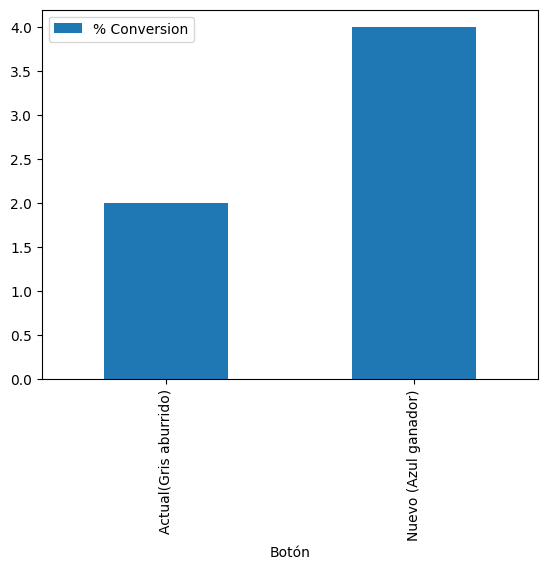

In [29]:
pd.DataFrame({'Botón':['Actual(Gris aburrido)','Nuevo (Azul ganador)'],'% Conversion':[2,4]}).plot(kind ='bar',x='Botón',y='% Conversion')

## Diseño de la prueba A/B (Clicks)


### **Definir hipótesis**

* $H_0:$ El botón nuevo tiene el mismo o menor promedio de clics que el botón actual   $\mu_b \geq \mu_a$

* $H_1:$ El botón nuevo tiene un mayor promedio de clics que el botón actual   $\mu_b < \mu_a$


### **Nivel de significancia $\alpha$**

Definos una significancia del 0.05


In [40]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu



In [33]:
clics_b = buttom_color_dataset.query('Variant == "B"').Clicks.to_list()
clics_a = buttom_color_dataset.query('Variant == "A"').Clicks.to_list()
alpha=0.05

In [34]:
stat,p_value = ttest_ind(clics_b,clics_a, alternative='less')

In [41]:
stat,p_value = mannwhitneyu(clics_b,clics_a, alternative='less')

In [42]:
print(f"Tenemos un {p_value=:.3f} entonces con {alpha=} ")
if p_value > alpha:
    print(f"Hay evidencia de que las media de clics de B es igual o mayor que la de A")
else:
    print(f"No hay evidencia de que las media de clics de B es igual o mayor que la de A")

Tenemos un p_value=0.464 entonces con alpha=0.05 
Hay evidencia de que las media de clics de B es igual o mayor que la de A


### **Conclusión**

Aunque la tasa de conversión con el botón nuevo resultó mejor que con el botón actual, no encontramos mejoria significativa en la fricción del cliente en el proceso de compra, ya que en la cantidad de clics promedio no encontramos una mejora

In [38]:
sns.set(style="whitegrid", palette="pastel")


<Axes: xlabel='Variant', ylabel='Clicks'>

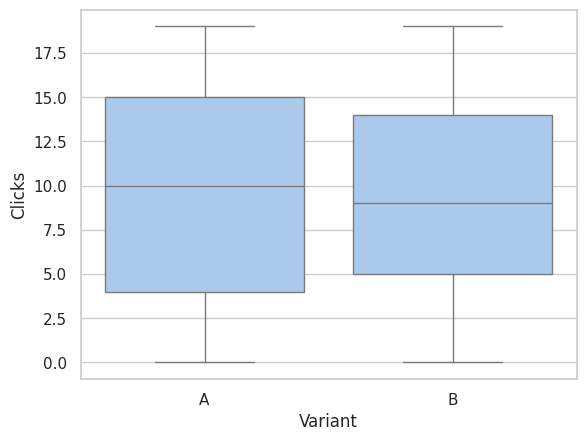

In [39]:
sns.boxplot(data=buttom_color_dataset, x='Variant',y='Clicks')

## ✨ En conclusión (5 Min)

---

Antes de cerrar, me  gustaría saber tu opinión:

- ¿Qué fue lo más útil o interesante que aprendiste hoy?
- ¿Qué parte te resultó más difícil o te gustaría repasar?
- ¿Te sentiste cómodo/a participando en la dinámica grupal?
- ¿Qué sugerencias tienes para futuras sesiones?



## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 10](https://discord.com/channels/1081207584104656986/1271522536156561521).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨